# CMPT 413 / 713 Tutorial 7

## Text Generation with PyTorch using RNNs

## Load the AG News Dataset from Previous Tutorials

In [1]:
# Load the AG NEWS dataset from the torchtext library
import torch
import torchtext

train_dataset, val_dataset = torchtext.datasets.AG_NEWS()

## Basic preprocessing of text

1. Lower Case: 'He is walking around the park.' -> 'he is walking around the park.'
2. Remove Punctuation: 'he is walking around the park.' -> 'he is walking around the park'
3. Stem: 'he is walking around the park' -> 'he is walk around the park'

In [2]:
# Some basic preprocessing of text dataset
import io
import nltk
import string
import numpy as np
from tqdm import tqdm
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
  
stemmer = PorterStemmer()

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree

# Function to tokenize text
def tokenization(text):
    tokens = word_tokenize(text)
    return tokens

# Stem function for the words
def stem(text):
    stem_text = [stemmer.stem(word) for word in text]
    return stem_text

train_text = [data[1] for data in train_dataset]
val_text = [data[1] for data in val_dataset]

train_len = []
val_len = []

train_labels = np.array([item[0] for item in train_dataset]) - 1
val_labels = np.array([item[0] for item in val_dataset]) - 1

print('Original Text:')
print(train_text[0])
temp = train_text[0].lower()
print()
print('Lower Case:')
print(temp)
temp = remove_punctuation(temp)
print()
print('Remove Punctuation:')
print(temp)
temp = tokenization(temp)
print()
print('Tokenization:')
print(temp)
temp = stem(temp)
print()
print('Stem:')
print(temp)

for i in tqdm(range(len(train_text))):
    train_text[i] = train_text[i].lower()
    train_text[i] = remove_punctuation(train_text[i])
    train_text[i] = tokenization(train_text[i])
    train_text[i] = stem(train_text[i])
    train_len.append(len(train_text[i]))
    
for i in tqdm(range(len(val_text))):
    val_text[i] = val_text[i].lower()
    val_text[i] = remove_punctuation(val_text[i])
    val_text[i] = tokenization(val_text[i])
    val_text[i] = stem(val_text[i])
    val_len.append(len(val_text[i]))
    
train_len = np.array(train_len)
val_len = np.array(val_len)

[nltk_data] Downloading package punkt to /home/rexlee/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rexlee/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/rexlee/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /home/rexlee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original Text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Lower Case:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.

Remove Punctuation:
wall st bears claw back into the black reuters reuters  shortsellers wall streets dwindlingband of ultracynics are seeing green again

Tokenization:
['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'of', 'ultracynics', 'are', 'seeing', 'green', 'again']

Stem:
['wall', 'st', 'bear', 'claw', 'back', 'into', 'the', 'black', 'reuter', 'reuter', 'shortsel', 'wall', 'street', 'dwindlingband', 'of', 'ultracyn', 'are', 'see', 'green', 'again']


100%|█████████████████████████████████████████████████████████████████████████████| 7600/7600 [00:02<00:00, 3629.13it/s]


## Convert words to integers

1. We want to build a vocabulary dictionary that converts words to integers eg. 'I' -> 13.
2. We want to avoid words that don't appear often. Here we use an arbitrary threshold of at least 10 occurences.
3. Add \<START> for the first token in the sentence.
4. Add \<UNK> for words that are not in vocab (occurence < 10).

In [3]:
# Get word to number mapping for word counts that are over 10
from collections import Counter

counter = Counter()
for sentence in tqdm(train_text):
    counter.update(sentence)

# Here we only get words that appears more than 10 times
counter = Counter({k: c for k, c in counter.items() if c >= 10})
vocab = list(counter.keys())
word_counter = counter

vocab_to_id = {}
vocab_to_id['<START>'] = 0
vocab_to_id['<UNK>'] = 1

counter = 2
for word in vocab:
    vocab_to_id[word] = counter
    counter += 1
vocab_size = counter
print('Vocab Size:', counter)

100%|███████████████████████████████████████████████████████████████████████| 120000/120000 [00:00<00:00, 359073.45it/s]

Vocab Size: 15089


## Custom Dataset Loader

### Dataset Class
1. In the Dataset class we convert sentences into integer numbers using the vocab_to_id dictionary.
2. We do not need to pad sentences as RNNs can handle variable lengths
3. Here the ground truth labels we want to predict are just the next word in the sentence.

### Collate Function
1. We first sort all sentences by descending order. This is to enable batching and parallel evaluations of RNNs since each sentence might have different lengths.
2. We use nn.utils.rnn.pack_sequence from PyTorch to pack the sentences together. The batch_sizes variable in the data structure keeps track of how many words in parallel to feed the RNN.

In [26]:
# Custom dataset loader
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, text_dataset, vocab_to_id):
        super(TextDataset, self).__init__()
        self.text_dataset = text_dataset
        self.vocab_to_id = vocab_to_id

    def __len__(self):
        return len(self.text_dataset)

    def __getitem__(self, idx):
        text = self.text_dataset[idx]
        
        # Convert all words into their corresponding ids in vocab
        # Add <START> tokens to beginning of every setence
        tokens = [self.vocab_to_id['<START>']]
        for counter in range(len(text)):
            if text[counter] in self.vocab_to_id.keys():
                tokens.append(self.vocab_to_id[text[counter]])
            else:
                tokens.append(self.vocab_to_id['<UNK>'])
        x = tokens[:-1]
        y = tokens[1:]
        return x, y
    
def collate(batch):
    Xs = []
    Ys = []
    for item in batch:
        Xs.append(item[0])
        Ys.append(item[1])
    # Sort the input and label sentences by descending order
    Xs.sort(key=lambda l: len(l), reverse=True)
    Ys.sort(key=lambda l: len(l), reverse=True)
    Xs = [torch.LongTensor(x) for x in Xs]
    Ys = [torch.LongTensor(y) for y in Ys]
    # Use pack_sequence in PyTorch to pack the tokens together
    x = nn.utils.rnn.pack_sequence(Xs)
    y = nn.utils.rnn.pack_sequence(Ys)
    return x, y
    
train_dataset = TextDataset(train_text, vocab_to_id)
train_dataloader = DataLoader(train_dataset, collate_fn=collate, batch_size=32, shuffle=True, num_workers=4)

val_dataset = TextDataset(val_text, vocab_to_id)
val_dataloader = DataLoader(val_dataset, collate_fn=collate, batch_size=32, num_workers=4)

print('Sentence 1: ', ' '.join(['<START>'] + val_text[21]))
print('Tokenized: ', val_dataset[21][0])
print()
print('Sentence 2: ', ' '.join(['<START>'] + val_text[578]))
print('Sentence 2: ', val_dataset[578][0])
print()
print('Ground Truth Label 1: ', val_dataset[21][1])
print('Ground Truth Label 2: ', val_dataset[578][1])
print()
print(nn.utils.rnn.pack_sequence([torch.LongTensor(val_dataset[578][0]), torch.LongTensor(val_dataset[21][0])]))

Sentence 1:  <START> sun look glass provid 3d view develop get earli code for new oper system skin still be craft
Tokenized:  [0, 1122, 18, 1123, 962, 1124, 894, 939, 333, 1125, 1126, 28, 79, 406, 903, 1127, 1128, 272]

Sentence 2:  <START> vonag awash in ventur capit voip defin upstart vonag ha quickli amass anoth 105 million from ventur capitalist and is look to latin america and asia to acceler an alreadi torrid growth rate
Sentence 2:  [0, 2851, 1960, 32, 2261, 255, 2759, 1873, 5234, 2851, 25, 2143, 10528, 38, 4735, 202, 61, 2261, 7535, 30, 142, 18, 75, 7851, 1074, 30, 763, 75, 7935, 71, 199, 8439, 307]

Ground Truth Label 1:  [1122, 18, 1123, 962, 1124, 894, 939, 333, 1125, 1126, 28, 79, 406, 903, 1127, 1128, 272, 1129]
Ground Truth Label 2:  [2851, 1960, 32, 2261, 255, 2759, 1873, 5234, 2851, 25, 2143, 10528, 38, 4735, 202, 61, 2261, 7535, 30, 142, 18, 75, 7851, 1074, 30, 763, 75, 7935, 71, 199, 8439, 307, 355]

PackedSequence(data=tensor([    0,     0,  2851,  1122,  1960,    18

## RNN Model

*Modified from https://github.com/florijanstamenkovic/PytorchRnnLM*
1. We use a GRU for the RNN model.
2. A final fully connected layer is used to predict the next word from the last output of the GRU.

In [11]:
class Rnn(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, gru_layers, dropout):
        super(Rnn, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, gru_layers, dropout=dropout)
        self.fc1 = nn.Linear(hidden_dim, vocab_size)

    def get_embedded(self, word_indexes):
        return self.embedding(word_indexes)

    def forward(self, X):
        embedded_sents = nn.utils.rnn.PackedSequence(self.get_embedded(X.data), X.batch_sizes)
        out_packed_sequence, _ = self.gru(embedded_sents)
        out = self.fc1(out_packed_sequence.data)
        return out

## Training

1. Training is mostly the same as last time.
2. Hyperparameters: Embedding Dim: 256, Hidden Dim: 512, GRU Layers: 2, Dropout: 0.2
3. We see lower perplexity and higher accuracy compared to last time.

In [12]:
from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
from sklearn.metrics import accuracy_score

loss_fn = nn.CrossEntropyLoss()
model = Rnn(vocab_size, 256, 512, 2, 0.1).cuda()
optimizer = Adam(model.parameters(), lr=0.001)

def cal_loss_and_accuracy(model, loss_fn, val_data_loader):
    entropy_sum = 0
    word_count = 0
    with torch.no_grad():
        y_actual, y_preds, losses, perplexities = [],[],[],[]
        for x, y in val_data_loader:
            y_cuda = y.cuda()
            x_cuda = x.cuda()
            preds = model(x_cuda)
            loss = loss_fn(preds, y_cuda.data)
            losses.append(loss.item())
            y_actual.append(y_cuda.data)
            y_preds.append(preds.argmax(dim=-1))
            perplexities.append(np.power(2, loss.item()))

        y_actual = torch.cat(y_actual)
        y_preds = torch.cat(y_preds)
        perplexities = np.array(perplexities)

        print("Val Loss: {:.3f}".format(torch.tensor(losses).mean()))
        print("Val Perplexity: {:.3f}".format(perplexities.mean()))
        print("Val Accuracy: {:.3f}".format(accuracy_score(y_actual.cpu().numpy(), y_preds.cpu().numpy())))

# train the model 5 epochs
for i in range(5):
    losses = []
    for x, y in tqdm(train_dataloader):
        x, y = x.cuda(), y.cuda()
        
        # forward
        y_preds = model(x)
        
        # calculate losses
        loss = loss_fn(y_preds, y.data)
        losses.append(loss.item())
        
        # empty old gradients
        optimizer.zero_grad()
        
        # calculate gradients and backward
        loss.backward()
        
        # update all parameters
        optimizer.step()

    print("Train Loss : {:.3f}".format(torch.tensor(losses).mean()))
    cal_loss_and_accuracy(model, loss_fn, val_dataloader)

100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:39<00:00, 94.41it/s]

Train Loss : 6.276


Val Loss: 5.283
Val Perplexity: 39.224
Val Accuracy: 0.180


100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:38<00:00, 96.52it/s]

Train Loss : 4.959


...

Train Loss : 4.358


Val Loss: 4.673
Val Perplexity: 25.796
Val Accuracy: 0.231


100%|███████████████████████████████████████████████████████████████████████████████| 3750/3750 [00:41<00:00, 89.67it/s]

Train Loss : 4.222


Val Loss: 4.658
Val Perplexity: 25.552
Val Accuracy: 0.233


## Validation accuracy function

In [13]:
from sklearn.metrics import classification_report

y_actual, y_preds = [], []

# test the model
with torch.no_grad():
    for x, y in val_dataloader:
        preds = model(x.cuda())
        
        y_preds.append(F.softmax(preds, dim=-1).argmax(dim=-1).cpu())
        y_actual.append(y.data)
    
    y_preds, y_actual = torch.cat(y_preds), torch.cat(y_actual)
    
    
# print results
print("Accuracy : {}".format(accuracy_score(y_actual, y_preds)))
print("\nClassification Report : ")
print(classification_report(y_actual, y_preds))

Accuracy : 0.23269137823373562

Classification Report : 


/home/rexlee/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/rexlee/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           1       0.10      0.33      0.16      9094
           2       0.38      0.20      0.26        90
           3       0.28      0.23      0.26       103
           4       0.62      0.20      0.30        25
           5       0.00      0.00      0.00         1
           6       0.29      0.09      0.14       303
           7       0.25      0.17      0.20       447
           8       0.22      0.56      0.32     12858
           9       0.26      0.14      0.18        44
          10       0.42      0.62      0.50      1037
          11       0.71      0.68      0.70       119
          12       0.37      0.67      0.48      6155
          13       0.08      0.09      0.08       603
          14       0.06      0.02      0.03       124
          15       0.37      0.11      0.17        62
          16       0.16      0.07      0.10        98
          18       0.02      0.01      0.01       194
          19       0.43    

/home/rexlee/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/rexlee/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/rexlee/miniconda3/envs/py38/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/

## Choose Words for Plotting

1. We want to plot some word embeddings from the learned network.
2. We choose 105 common words and skip the top 45 since it is mostly words like "a", "the" which is less meaningful.

In [21]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = (10,10)

words = [item[0] for item in word_counter.most_common(150)[45:]]
tokens = [vocab_to_id[word] for word in words]
tokens = torch.LongTensor(tokens).cuda()

print(words)

['game', 'monday', 'wednesday', 'tuesday', 'out', 'oil', 'one', 'thursday', 'not', 'against', 'price', 'inc', 'week', 'friday', 'win', 'state', 'into', 'plan', 'unit', 'last', 'about', 'iraq', 'than', 'york', 'they', 'kill', 'yesterday', 'presid', 'who', 'million', 'secur', 'microsoft', 'quot', 'were', 'time', 'nation', 'no', 'been', 'offici', 'day', 'group', 'open', 'had', 'govern', 'servic', 'corp', 'team', 'stock', 'when', 'market', 'back', 'sunday', 'end', 'announc', 'take', 'three', 'could', 'lead', 'would', 'today', 'peopl', 'make', 'which', 'sale', 'may', 'afp', 'share', 'percent', 'softwar', 'get', 'month', 'busi', 'profit', 'deal', 'use', 'off', 'next', 'season', 'record', 'minist', 'saturday', 'second', 'night', 'help', 'or', 'top', 'comput', 'china', 'offer', 'internet', 'expect', 'set', 'leader', 'other', 'attack', 'can', 'releas', 'some', 'elect', 'intern', 'call', 'talk', 'american', 'network', 'countri']


## Plot the Word Embeddings

Finally we plot the words. We can see some words with related semantics being close to each other.
1. Days of the week: monday, tuesday, thursday, ...
2. Numbers: second, three, last, ...

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


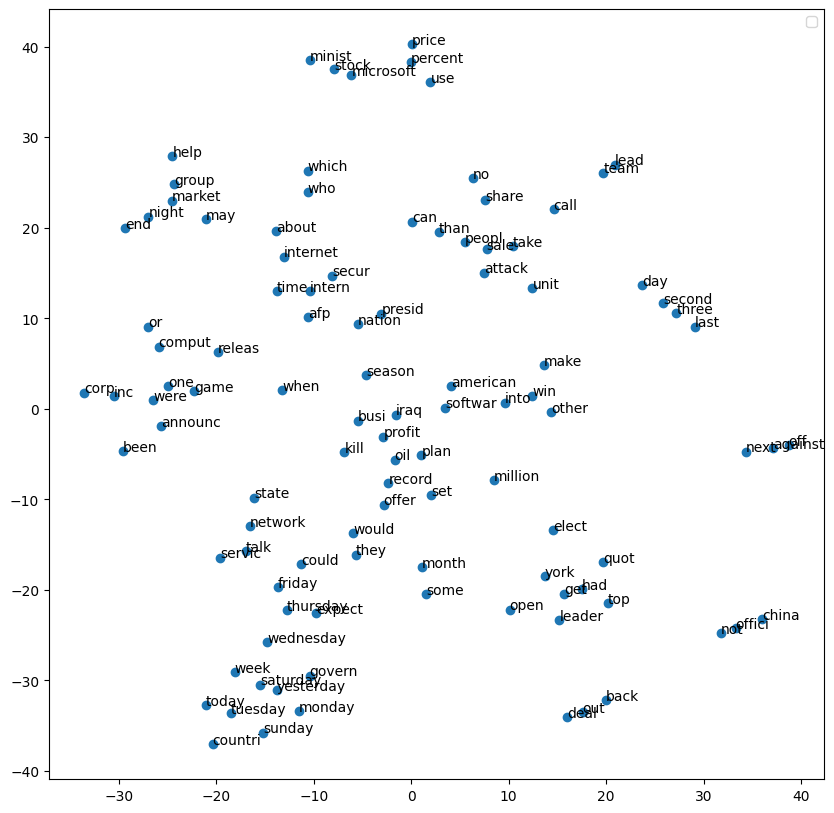

In [22]:
embeddings = model.get_embedded(tokens).detach().cpu().numpy()
X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(embeddings)

fig, ax = plt.subplots()
ax.scatter(X_embedded[..., 0], X_embedded[..., 1])
for idx, word in enumerate(words):
    ax.annotate(word, (X_embedded[idx, 0], X_embedded[idx, 1]))
ax.legend()
plt.show()

## Exercise

This dataset is actually not great for text generation for a couple of reasons.
1. The text is from news and focuses on only a few classes. This may make it less general for other types of text.
2. The dataset is still comparitively small.

For exercise you can try loading the WikiText103(https://pytorch.org/text/stable/datasets.html#wikitext103) or Bookcorpus(https://pytorch.org/text/stable/datasets.html#wikitext103) instead. Plot the embeddings and see if there are better semantic relations.